In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from model_multi import LogisticRegressionMultiExpert
from data import get_dataloaders, ExpertMNIST
from l2d_functionality.l2d_loss_multi import L2D_MultiExpertLoss
from l2d_functionality.l2d_eval_multi import L2D_Eval_Multi_Expert

In [2]:
# MNIST setup
input_dim = 28 * 28
num_classes = 10
num_epochs = 5
learning_rate = 1e-5
l2_lambda = 0.0   # regularization
batch_size = 64

expert_probs = [0.99, 0.9]
num_experts = len(expert_probs)

output_dim = num_classes + num_experts

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda t: torch.flatten(t))
])

train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Generate expert labels for each expert
expert_labels_train = []
expert_labels_test = []
for prob in expert_probs:
    expert = ExpertMNIST(prob)
    expert_labels_train.append(torch.tensor([expert.expert_prediction(lbl) for _, lbl in train_raw]))
    expert_labels_test.append(torch.tensor([expert.expert_prediction(lbl) for _, lbl in test_raw]))

expert_labels_train = torch.stack(expert_labels_train, dim=1)
expert_labels_test  = torch.stack(expert_labels_test, dim=1)

train_loader, test_loader = get_dataloaders(train_raw, expert_labels_train,
                                            test_raw, expert_labels_test,
                                            batch_size=batch_size)

In [4]:
model = LogisticRegressionMultiExpert(input_dim, num_classes, num_experts, l2_lambda)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
losses = []


Epoch 1/5, Loss=5.7878
Epoch 2/5, Loss=3.8306
Epoch 3/5, Loss=3.1777
Epoch 4/5, Loss=2.7482
Epoch 5/5, Loss=2.4492


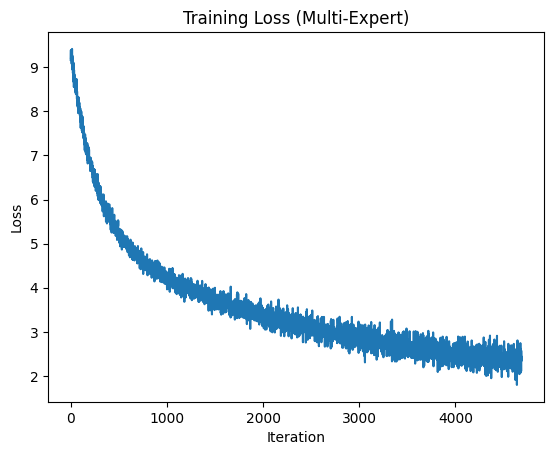

In [5]:
l2d = L2D_MultiExpertLoss(num_classes, num_experts)

for epoch in range(num_epochs):
    for images, labels, expert_labels_batch in train_loader:
        outputs = model(images)

        loss = l2d.loss_fn(outputs, labels, expert_labels_batch, param_type="one_vs_all")
        loss += model.l2_regularization()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    print(f"Epoch {epoch+1}/{num_epochs}, Loss={np.mean(losses[-len(train_loader):]):.4f}")

# Plot training curve
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss (Multi-Expert)")
plt.savefig("training_loss_multi.png")
plt.show()

=== Model Report ===
Test Accuracy of Pure Classifier: 82.92%
Test Accuracy (excluding deferrals): 90.99%
Deferral Accuracy (Experts): 74.28%
Overall Deferral Rate: 61.71%
Overall Combined Accuracy: 80.68%

=== Per-Class Report ===
Class 0: Accuracy (non-deferred) = 96.84%, Deferral Rate = 16.12%, Overall Accuracy = 81.22%
Class 1: Accuracy (non-deferred) = 94.51%, Deferral Rate = 91.98%, Overall Accuracy = 97.80%
Class 2: Accuracy (non-deferred) = 91.13%, Deferral Rate = 21.32%, Overall Accuracy = 71.71%
Class 3: Accuracy (non-deferred) = 89.36%, Deferral Rate = 86.04%, Overall Accuracy = 97.62%
Class 4: Accuracy (non-deferred) = 95.57%, Deferral Rate = 44.81%, Overall Accuracy = 52.75%
Class 5: Accuracy (non-deferred) = 43.88%, Deferral Rate = 89.01%, Overall Accuracy = 92.83%
Class 6: Accuracy (non-deferred) = 93.82%, Deferral Rate = 12.11%, Overall Accuracy = 82.46%
Class 7: Accuracy (non-deferred) = 70.37%, Deferral Rate = 97.37%, Overall Accuracy = 98.64%
Class 8: Accuracy (non-d

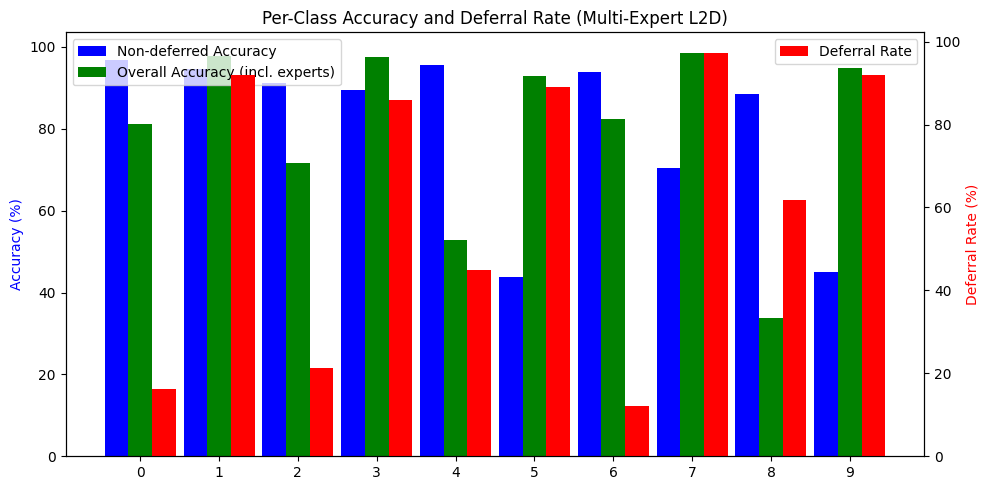

In [6]:
all_outputs = []
all_labels = []
all_expert_labels = []

with torch.no_grad():
    for images, labels, expert_labels in test_loader:
        outputs = model(images)
        all_outputs.append(outputs)
        all_labels.append(labels)
        all_expert_labels.append(expert_labels)

all_outputs = torch.cat(all_outputs, dim=0)
all_labels = torch.cat(all_labels, dim=0)
all_expert_labels = torch.cat(all_expert_labels, dim=0)

l2d_eval = L2D_Eval_Multi_Expert(num_classes, all_outputs, all_labels, all_expert_labels)

print("=== Model Report ===")
model_report = l2d_eval.model_report()

print("\n=== Per-Class Report ===")
per_class_report = l2d_eval.per_class_report()

print("\n=== Expert Report ===")
expert_report = l2d_eval.expert_report()

l2d_eval.visualize_per_class_metrics("per_class_metrics_multi.png")
